# Preparing a Uniformly Distributed State
$$
\renewcommand{\ket}[1]{|#1\rangle}
\renewcommand{\bra}[1]{\langle#1|}
$$

In this tutorial, we will review Workbench Algorithms Qubricks for preparing a uniformly distributed state.

The problem statement is as follows. Given $d$ basis states to include in the distribution, prepare the state, 

$$
\frac{1}{\sqrt{d}} \sum_{i=0}^{d-1} \ket{i}.
$$

If $d$ is a power of 2, this is easy as we can just apply Hadamards. Otherwise, we have to do something more clever.
Workbench Algorithms offers three Qubricks that do this: 
[$\text{USP}$](https://construct.psiquantum.com/docs/psiqdk-algorithms/autoapi/psiqdk/algorithms/state_preparation/index.html#psiqdk.algorithms.state_preparation.USP), [$\text{RealUSP}$](https://construct.psiquantum.com/docs/psiqdk-algorithms/autoapi/psiqdk/algorithms/state_preparation/index.html#psiqdk.algorithms.state_preparation.RealUSP) and [$\text{ZeroAncillaUSP}$](https://construct.psiquantum.com/docs/psiqdk-algorithms/autoapi/psiqdk/algorithms/state_preparation/index.html#psiqdk.algorithms.state_preparation.ZeroAncillaUSP).

The first two Qubricks utilize amplitude amplification. The last utilizes controlled Ry rotations and controlled Hadamards to perform state preparation without any auxiliary qubits.

The `compute` method of all three qubricks takes two arguments: the target register (`target_qreg`, type Qubits) and the number of amplitudes (`d`, type int). 
If you want to perform controlled state preparation, you can additionally pass a control register (`ctrl`, type Qubits).

All three implementations utilize rotation gates. Optionally, you can also provide an error parameter determining the accuracy of truncated rotation angles (`error_param`, type float). If an error parameter is not provided, angles are treated as exact and the probability of success is 1.0.

In [1]:
import numpy as np
from psiqdk.workbench import QPU, Qubits
from psiqdk.algorithms import RealUSP, USP, ZeroAncillaUSP

## USP

This Qubrick implements Figure 12 in "Encoding Electronic Spectra in Quantum Circuits with Linear T Complexity" ([arXiv:1805.03662](https://arxiv.org/abs/1805.03662)).

Conceptually, this routine starts by factoring $d = 2^k L$. Just applying Hadamard gates creates the desired equal superposition over the least significant $k$ qubits. For the remaining qubits we need to also perform amplitude amplification to keep only basis states with value < d. 

The optimal angle of reflection is

$$\theta = arccos( - \frac{2^{\lfloor log(L) \rfloor} - L }{L} )$$

which has a minus sign correction from the original reference.

> Importantly, this routine will prepare the desired state up to a global phase.
> In the uncontrolled case, this does not result in any measurable effect. However, if we're utilizing state vector simulation, we will need to utilize fidelity rather than equality testing.
> Moreover, this global phase can become important if you apply a controlled variant of this Qubrick, which can introduce local phase errors if you don't apply additional phase fix-up!

The following example shows how to use `USP` to prepare a uniform state:

Output state for d=14
|reg|?>
|0|.>    -0.142857+0.225877j
|1|.>    -0.142857+0.225877j
|2|.>    -0.142857+0.225877j
|3|.>    -0.142857+0.225877j
|4|.>    -0.142857+0.225877j
|5|.>    -0.142857+0.225877j
|6|.>    -0.142857+0.225877j
|7|.>    -0.142857+0.225877j
|8|.>    -0.142857+0.225877j
|9|.>    -0.142857+0.225877j
|10|.>    -0.142857+0.225877j
|11|.>    -0.142857+0.225877j
|12|.>    -0.142857+0.225877j
|13|.>    -0.142857+0.225877j


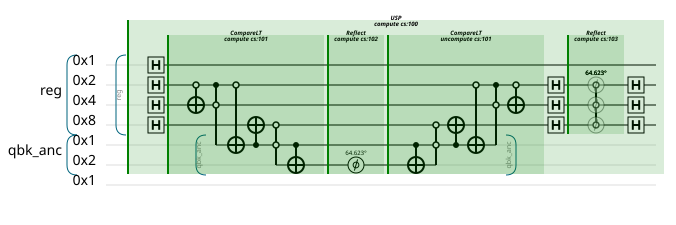

In [2]:
n_tgt = 4
d = 14

qpu = QPU(num_qubits = n_tgt + (n_tgt-1))
reg = Qubits(n_tgt, "reg", qpu)

# Prepare the uniform state
USP().compute(d=d, target_qreg=reg)

print(f'Output state for {d=}')
qpu.print_state_vector()
qpu.draw(show_qubricks=True)

# Check amplitudes explicitly
state = qpu.pull_state()
assert np.allclose(np.abs(state[:d]), np.ones(d) * 1 / np.sqrt(d))

## RealUSP

"Even more efficient quantum computations of chemistry through tensor hypercontraction" ([arxiv:2011.03494](https://arxiv.org/abs/2011.03494)) presents an alternative implementation also based on amplitude amplification.

It uses one auxiliary qubit called the ‘rotator’. This qubit is first rotated by the optimal angle stated above. After this, the reflections (now including the rotator qubit) can be performed by just a CZ gate.

> Since this routine uses Ry rotations, the resulting amplitudes are always real.
> The uncontrolled variant of this Qubrick still introduces a global phase of −1. However, its controlled variant automatically applies an additional phase fixup (a Z gate on the control), making sure that no local phase error is introduced.

The following example shows how to use `RealUSP` to prepare a uniform state:

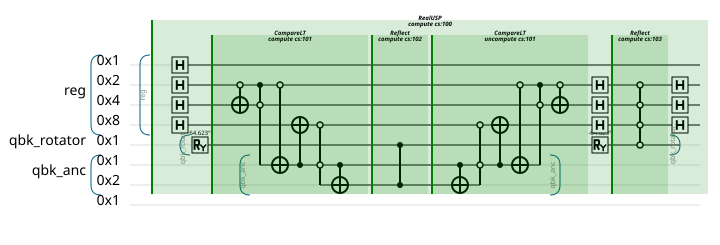

|reg|?>
|0|.>    -0.267261+0.000000j
|1|.>    -0.267261+0.000000j
|2|.>    -0.267261+0.000000j
|3|.>    -0.267261+0.000000j
|4|.>    -0.267261+0.000000j
|5|.>    -0.267261+0.000000j
|6|.>    -0.267261+0.000000j
|7|.>    -0.267261+0.000000j
|8|.>    -0.267261+0.000000j
|9|.>    -0.267261+0.000000j
|10|.>    -0.267261+0.000000j
|11|.>    -0.267261+0.000000j
|12|.>    -0.267261+0.000000j
|13|.>    -0.267261+0.000000j


In [3]:
qpu = QPU(num_qubits= 2 * n_tgt)
reg = Qubits(n_tgt, "reg", qpu)

# Prepare the uniform state 
RealUSP().compute(d=d, target_qreg=reg)

qpu.draw(show_qubricks=True)
qpu.print_state_vector()

# Check amplitudes explicitly
state = qpu.pull_state()
assert np.allclose(np.abs(state[:d]), np.ones(d) * 1 / np.sqrt(d))

> Note you can optionally provide the auxiliary qubit to the compute (`rotator`, type Qubits).

## ZeroAncillaUSP

"An efficient quantum algorithm for preparation of uniform quantum superposition states" ([arxiv:2306.11747](https://arxiv.org/abs/2306.11747)) presents a method that uses the binary decomposition of $d$, controlled Ry rotations and controlled Hadamards to construct a uniform state without any auxiliary qubits.

> Again, since we are using Ry gates only, the amplitudes will be real. This routine prepares the state without phase error.

The following example shows how to use `ZeroAncillaUSP` to prepare a uniform state:

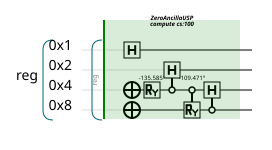

|reg>
|0>    0.267261+0.000000j
|1>    0.267261+0.000000j
|2>    0.267261+0.000000j
|3>    0.267261+0.000000j
|4>    0.267261+0.000000j
|5>    0.267261+0.000000j
|6>    0.267261+0.000000j
|7>    0.267261+0.000000j
|8>    0.267261+0.000000j
|9>    0.267261+0.000000j
|10>    0.267261+0.000000j
|11>    0.267261+0.000000j
|12>    0.267261+0.000000j
|13>    0.267261+0.000000j


In [4]:
qpu = QPU(num_qubits=n_tgt)
reg = Qubits(n_tgt, "reg", qpu)

# Prepare the uniform state 
ZeroAncillaUSP().compute(d=d, target_qreg=reg)

qpu.draw(show_qubricks=True)
qpu.print_state_vector()

# Check amplitudes explicitly
state = qpu.pull_state()
assert np.allclose(np.abs(state[:d]), np.ones(d) * 1 / np.sqrt(d))

## Resource analysis of USP variants

We can compare the QREs for these three implementations. We will generate the circuit (but not simulate the state vector) for a quantum state with d=10,000 uniform amplitudes.

In [5]:
from psiqdk.workbench.qre import resource_estimator
from psiqdk.workbench.filter_presets import NO_SIM_DEFAULT

def get_resources_usp(qbk):
    d = 10000
    n_tgt = 14

    qpu = QPU(num_qubits= 2*n_tgt, filters = NO_SIM_DEFAULT)
    reg = Qubits(n_tgt, "reg", qpu)

    qbk().compute(d=d, target_qreg=reg)

    resources = resource_estimator(qpu).resources()
    return (resources['toffs'] + resources['gidney_lelbows'],
            resources['qubit_highwater'], 
            resources['active_volume']
           )

print(f"| USP Qubrick      | Toffoli gates | Qubits | Active Volume |")
for qbk in [USP, RealUSP, ZeroAncillaUSP]:
    resources = get_resources_usp(qbk)
    print(f"| {qbk.__name__.ljust(16)} "
          f"| {str(resources[0]).ljust(13)} "
          f"| {str(resources[1]).ljust(7)}"
          f"| {str(resources[2]).ljust(13)} |")


| USP Qubrick      | Toffoli gates | Qubits | Active Volume |
| USP              | 17            | 23     | 4579          |
| RealUSP          | 18            | 24     | 2894          |
| ZeroAncillaUSP   | 0             | 14     | 6816          |


We see that while `RealUSP` uses one additional qubit and one additional Toffoli, the active volume for `USP` is approximately 1.5 times larger due to the multiple arbitrary angle phase gates. The active volume is the highest for `ZeroAncillaUSP` which utilizes no Toffoli gates and no additional qubits but incurs significant costs from the multiple (controlled) arbitrary angle rotation gates. 

Which routine is best in practice will depend both on the choice of $d$ and the specifics of the compilation stack!

## Summary

In this tutorial, we walked through preparing a uniformly distributed state on a QPU and the different options Workbench Algorithms offers for this.

- $\text{USP}$ utilizes amplitude amplification techniques to prepare the desired distribution up to a complex phase.
- $\text{RealUSP}$ also utilizes amplitude amplification techniques but instead of phase gates uses one additional auxiliary qubit and Ry rotation to prepare the desired distribution up to a -1 phase.
- $\text{ZeroAncillaUSP}$ avoids any auxiliary qubits by using controlled Ry and Hadamards across the register to prepare the desired distribution. It incurs significant active volume cost from the many arbitrary rotation gates.

Have fun preparing uniform distributions!